In [1]:
library(ggplot2)
library(dplyr)
library(gridExtra)
library(cowplot)
library(ggrepel)
library(grid)
library(ggsci)
library(ggtext)
library(gtable)
library(ggrastr)
library(stringr)
library(tidyverse)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘gridExtra’ was built under R version 4.3.3”

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Warning message:
“package ‘cowplot’ was built under R version 4.3.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”
Warning message:
“package ‘ggsci’ was built under R version 4.3.3”
Warning message:
“package ‘ggtext’ was built under R version 4.3.3”
Warning message:
“package ‘gtable’ was built under R version 4.3.3”
Warning message:
“package ‘ggrastr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning mes

In [2]:
load("/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_spearte_gender_nature.Rdata")

In [16]:
 #age not scale; correct gender
olink <- read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_age_liner_gender_FDR.csv",row.names=1) 
cytokine <- read.csv("/vol/projects/yzhang/500FG_aging/output/01_cytokine/cytokine_age_liner_gender_FDR.csv",row.names=1)
metabolite <- read.csv("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_age_linear_gender_FDR.csv",row.names=1) 
methylation <- readRDS("/vol/projects/yzhang/500FG_aging/output/05_methylation/methylation_age_liner_gender_FDR.RDS") 
# rownames(methylation)<-methylation$X
# methylation$X <- NULL
methylation <- methylation %>% rename(feature = Mvalue)
hormone <- read.csv("/vol/projects/yzhang/500FG_aging/output/06_hormone/hormone_age_liner_gender_FDR.csv",row.names=1)
cellcounts <- read.csv("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_age_rawless_gender_FDR.csv",row.names=1)  
immunoglobulin <- read.csv("/vol/projects/yzhang/500FG_aging/output/08_immunoglobulin/immunoglobulin_age_gender_FDR.csv",row.names=1)
microbiome <- read.csv("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_age_gender_FDR.csv",row.names=1)
platelet<- read.csv("/vol/projects/yzhang/500FG_aging/output/09_platelet/platelet_age_gender_FDR.csv",row.names=1)

head(olink)
head(cytokine)
head(metabolite)
head(methylation)
head(cellcounts)
head(microbiome)
head(hormone)
head(immunoglobulin)
head(platelet)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IL8,1.857226e-03,1.605897e-07,1.261852e-02,1.405159e-06,sig
Estimate1,VEGFA,3.326290e-04,2.074781e-03,8.924529e-04,6.051445e-03,sig
Estimate2,CD8A,-1.732231e-03,1.947852e-06,-9.891808e-03,1.136247e-05,sig
Estimate3,CDCP1,8.233146e-03,1.164648e-42,3.452471e-01,8.152538e-41,sig
Estimate4,CD244,-1.948333e-05,9.125587e-01,-7.742512e-07,9.257842e-01,no
Estimate5,IL7,1.341586e-03,3.960574e-02,1.881228e-03,7.108723e-02,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IFNy_LPS_WB_48h,-1.489589e-03,0.0157429534,-2.685600e-03,0.057304350,no
Estimate1,IFNy_PHA_WB_48h,-1.248407e-03,0.1019912047,-1.237717e-03,0.257610692,no
Estimate2,IFNy_C.conidiaHK_WB_48h,-2.449299e-03,0.0004847994,-8.118050e-03,0.002757296,sig
Estimate3,IFNy_S.aureus_WB_48h,-1.828313e-03,0.0112181557,-3.565355e-03,0.050387503,no
Estimate4,IL1b_LPS_WB_48h,1.086956e-04,0.5573738995,2.759275e-05,0.768500377,no
Estimate5,IL1b_PHA_WB_48h,-9.867128e-05,0.8021676676,-9.446280e-06,0.912465722,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Deoxynivalenol,-0.0021935538,1.463405e-02,-4.024372e-03,3.879725e-02,sig
Estimate1,Xenognosin A,0.0043140324,1.653234e-08,3.357036e-02,2.748502e-07,sig
Estimate2,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,-0.0022477068,8.116900e-02,-2.451371e-03,1.577902e-01,no
Estimate3,Cymarose,0.0002078031,6.635199e-01,3.701929e-05,7.537209e-01,no
Estimate4,Digitalose,0.0009722504,7.081403e-02,1.117972e-03,1.407462e-01,no
Estimate5,2-Naphthol,-0.0009047130,1.127605e-01,-8.575259e-04,2.036774e-01,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,cg00381604_BC11,-0.0013622451,0.41563686,-0.0005194049,0.7068243,no
Estimate1,cg00002271_BC21,-0.0013741588,0.11639210,-0.0012835694,0.3701592,no
Estimate2,cg00004581_TC21,0.0014710346,0.37799659,0.0006215299,0.6769167,no
Estimate3,cg09261435_BC21,-0.0011294722,0.55554164,-0.0002883355,0.8019698,no
Estimate4,cg00005473_TC21,-0.0007555015,0.38875621,-0.0003099994,0.6857682,no
Estimate5,cg00005474_TC21,0.0027755478,0.02548049,0.0044236464,0.1469979,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Granulocytes,0.0053116240,6.575255e-04,1.690205e-02,1.919974e-03,sig
Estimate1,Monocytes (CD14+),0.0027371700,1.226924e-01,2.494061e-03,1.722413e-01,no
Estimate2,Classical monocytes (CD14++CD16-),0.0003365318,8.606286e-01,2.193657e-05,9.105201e-01,no
Estimate3,Non-classical monocytes (CD14++CD16+),0.0106594533,7.996762e-07,6.499160e-02,3.441537e-06,sig
Estimate4,Intermediate monocytes (CD14+CD16+),0.0112041293,2.481781e-08,8.521005e-02,2.013000e-07,sig
Estimate5,T cells (CD3+ CD56-),-0.0056417279,1.308008e-04,-2.190903e-02,4.151505e-04,sig


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,PWY.6834..spermidine.biosynthesis.III,1.296846e-05,0.9545314,2.620895e-07,0.9976798,no
Estimate1,FERMENTATION.PWY..mixed.acid.fermentation,-5.972001e-04,0.6202431,-1.238820e-04,0.9976798,no
Estimate2,PWY.5686..UMP.biosynthesis,1.007802e-04,0.7923674,1.018620e-05,0.9976798,no
Estimate3,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,-2.188349e-05,0.9326019,-6.631511e-07,0.9976798,no
Estimate4,VALDEG.PWY..L.valine.degradation.I,3.496102e-06,0.9947422,8.004158e-09,0.9976798,no
Estimate5,PPGPPMET.PWY..ppGpp.biosynthesis,1.820142e-03,0.6194021,3.786394e-04,0.9976798,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,B_ADNC,-0.02501094,4.283096e-26,-0.63448350,3.854787e-25,sig
Estimate1,B_CORC,-0.02015736,2.037838e-17,-0.33644307,9.170270e-17,sig
Estimate2,B_DESC,-0.02048826,3.050586e-07,-0.13349364,6.663984e-07,sig
Estimate3,B_OHP,-0.01130764,3.791113e-03,-0.02737844,4.874289e-03,sig
Estimate4,B_PROG,-0.01576901,3.129267e-03,-0.03949439,4.693901e-03,sig
Estimate5,B_TESC,-0.01334730,2.096557e-09,-0.11583443,6.289670e-09,sig


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IgG,-0.0008073224,0.4688979843,-0.0002655458,0.5358834106,no
Estimate1,IgA,0.0108772125,0.0001071556,0.0431823702,0.0008572451,sig
Estimate2,IgM,-0.0053371194,0.0352829504,-0.0077518196,0.0705659008,no
Estimate3,IgG1,-0.0028358536,0.0174610334,-0.0049852323,0.0465627556,sig
Estimate4,IgG2,0.0061802909,0.0008521803,0.0189702083,0.0034087213,sig
Estimate5,IgG3,-0.0035759784,0.1547176510,-0.0028981880,0.2475482415,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,PLT_AP1,-0.0009190843,0.31381957,-0.0004625935,0.3835573,no
Estimate1,PLT_AF1,-0.0020392459,0.04864233,-0.0026775006,0.2012413,no
Estimate2,PLT_AP_AUC,0.0015022982,0.27211606,0.0008491678,0.3835573,no
Estimate3,PLT_AF_AUC,0.0022218860,0.26333792,0.0012875531,0.3835573,no
Estimate4,PLT_CP_AUC,-0.0011290399,0.45437515,-0.0003867926,0.4998127,no
Estimate5,PLT_CF_AUC,-0.0021594671,0.28776502,-0.0011681896,0.3835573,no


In [17]:
microbiome <- microbiome %>% rename(feature_old = feature)
microbiome $feature <- microbiome$feature_old %>%  
  str_remove("^PWY\\.\\d+\\.\\.?") %>%  
  str_remove("^[A-Z0-9]+\\.PWY\\.\\.?") %>% 
  str_replace_all("\\.", " ") %>%
  str_squish()

head(microbiome)

,feature_old,estimate,p,value,padj,sig,feature
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Estimate,PWY.6834..spermidine.biosynthesis.III,1.296846e-05,0.9545314,2.620895e-07,0.9976798,no,spermidine biosynthesis III
Estimate1,FERMENTATION.PWY..mixed.acid.fermentation,-5.972001e-04,0.6202431,-1.238820e-04,0.9976798,no,mixed acid fermentation
Estimate2,PWY.5686..UMP.biosynthesis,1.007802e-04,0.7923674,1.018620e-05,0.9976798,no,UMP biosynthesis
Estimate3,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,-2.188349e-05,0.9326019,-6.631511e-07,0.9976798,no,superpathway of L lysine L threonine and L methionine biosynthesis II
Estimate4,VALDEG.PWY..L.valine.degradation.I,3.496102e-06,0.9947422,8.004158e-09,0.9976798,no,L valine degradation I
Estimate5,PPGPPMET.PWY..ppGpp.biosynthesis,1.820142e-03,0.6194021,3.786394e-04,0.9976798,no,ppGpp biosynthesis


In [10]:
###nature style ###small size
create_combined_volcano_plot_nature <- function(data_list, titles, output_path) {
  # Title box background color per panel (same order as titles)
  color_palette <- setNames(
   # c("#B2DF8A", "#B3B3CC", "#FFFF99", "#FFCC99", "#A6CEE3", "#CAB2D6", "#e8d5b7", "#dcd6f7"),
      c("#B3DE69", "#FB8072", "#FFFFB3", "#80B1D3", "#BEBADA", "#FCCDE5", "#FDB462", "#8DD3C7"), 
    titles
  )

  # Unified colors for all panels: Positive = pink, Negative = blue (methylation style)
  col_pos <- "#FFB3E6"  #f1c0e8
  col_neg <- "#80B1D3"  #90dbf4
  col_ns <- "#B8B8B8"

  plots <- list()
  title_texts <- character(length(data_list))
  title_colors <- character(length(data_list))
    
  for (i in 1:length(data_list)) {
    data <- data_list[[i]]
    data <- data %>%
      mutate(
        sig = ifelse(padj < 0.05 & estimate > 0, "upregulated",
                     ifelse(padj < 0.05 & estimate < 0, "downregulated", "not significant")),
        log_padj = -log10(padj)
      )

    up_count <- sum(data$sig == "upregulated")
    down_count <- sum(data$sig == "downregulated")
    total_count <- nrow(data)
    up_pct <- round(up_count / total_count * 100, 1)
    down_pct <- round(down_count / total_count * 100, 1)

    top_upregulated <- data %>%
      filter(sig == "upregulated") %>%
      arrange(desc(log_padj)) %>%
      head(3)

    top_downregulated <- data %>%
      filter(sig == "downregulated") %>%
      arrange(desc(log_padj)) %>%
      head(3)

    top_combined <- bind_rows(top_upregulated, top_downregulated)

    category_with_stats <- paste0(titles[i], "\n",
                                  "Neg: ", down_count, " (", down_pct, "%) | ",
                                  "Pos: ", up_count, " (", up_pct, "%)")
    # Title with colored background via ggtext (HTML in ggtitle)
    title_texts[i] <- category_with_stats
    title_colors[i] <- color_palette[titles[i]]

    p <- ggplot(data, aes(x = estimate, y = log_padj)) +
      #geom_point(aes(color = sig), size = 2, alpha = 0.8) +
      ggrastr::geom_point_rast(aes(color = sig), size = 2, alpha = 0.8, raster.dpi = 300) +
      scale_color_manual(
        values = c(
          "upregulated" = col_pos,
          "downregulated" = col_neg,
          "not significant" = col_ns
        ),
        labels = c(
          "upregulated" = "Positive",
          "downregulated" = "Negative",
          "not significant" = "NS"
        )
      ) +
      geom_text_repel(
        data = top_combined,
        aes(x = estimate, y = log_padj, label = feature),
        size = 1.5,
        color = "black",
        box.padding = 0.5,
        point.padding = 0.3,
        min.segment.length = 0,
        max.overlaps = Inf,
        force = 4,
        segment.size = 0.3,
        segment.color = "grey50"
      ) +
      ggtitle(category_with_stats) +
      theme_classic() +
      theme(
        plot.title = element_text(size = 5, face = "bold", hjust = 0.5, lineheight = 1.1),
        axis.title = element_text(size = 5),
        axis.text = element_text(size = 5, color = "black"),
        axis.line = element_line(size = 0.5, color = "black"),
        axis.ticks = element_line(size = 0.5, color = "black"),
        legend.position = "bottom",
        legend.title = element_blank(),
        legend.text = element_text(size = 5),
        legend.margin = margin(0, 0, 0, 0),
        legend.box.margin = margin(-5, 0, 0, 0),
        legend.spacing.x = unit(4, "pt"),
        panel.border = element_rect(color = "black", fill = NA, size = 0.5),
        plot.margin = margin(6, 6, 8, 8)
      ) +
      xlab("Estimate") +
      ylab(expression(-log[10](P[adj])))

    plots[[i]] <- p
  }

  # Extract single legend (from first plot), then remove legend from all panels
  legend_grob <- cowplot::get_legend(plots[[1]])
  plots_no_leg <- lapply(plots, function(p) p + theme(legend.position = "none"))

  # Convert to grob, then replace title with custom grob (rect + text) so background color shows in PDF/PNG
   plot_grobs <- lapply(plots_no_leg, ggplotGrob)
   n_panels <- length(plot_grobs)
  for (i in seq_len(n_panels)) {
    gt <- plot_grobs[[i]]
    title_idx <- which(gt$layout$name == "title")
    if (length(title_idx) > 0L) {
      title_grob <- gTree(children = gList(
        rectGrob(gp = gpar(fill = title_colors[i], col = "black", lwd = 1)),
        textGrob(title_texts[i], x = 0.5, y = 0.5, default.units = "npc",
                 gp = gpar(fontsize = 5, fontface = "bold"), just = c("center", "center"))
      ))
      gt$grobs[[title_idx]] <- title_grob
      plot_grobs[[i]] <- gt
    }
  }
  combined_grob <- do.call(arrangeGrob, c(plot_grobs, list(ncol = 4, nrow = 2)))

  # Single legend at bottom center; minimal gap above legend (like attached image)
  final_grob <- arrangeGrob(combined_grob, legend_grob, nrow = 2, heights = c(1, 0.055))

  # Square-ish panels: 400mm wide (100mm per panel); height so each volcano ~square + title bar + one legend
  fig_width_mm <- 180
  fig_height_mm <- 200 * 185 / 400

  ggsave(output_path, plot = final_grob, width = fig_width_mm, height = fig_height_mm, units = "mm", device = "pdf")

  output_path_png <- sub("\\.pdf$", ".png", output_path, ignore.case = TRUE)
  ggsave(output_path_png, plot = final_grob, width = fig_width_mm, height = fig_height_mm, units = "mm", dpi = 300, device = "png")

  print(paste("PDF saved to:", output_path))
  print(paste("PNG saved to:", output_path_png))

  return(final_grob)
}

# Prepare data and titles
data_list <- list(methylation, olink, metabolite, cytokine, cellcounts, microbiome, hormone, immunoglobulin)
titles <- c("DNA methylation", "Proteomics", "Metabolomics", "Cytokine response", "Immune cell counts", "Microbiomes", "Circulating endocrine traits", "Circulating immune traits")

final_plot <- create_combined_volcano_plot_nature(
  data_list = data_list,
  titles = titles,
  output_path = "/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_plots_gender_nature_small.pdf"
)

print(final_plot)

[1] "PDF saved to: /vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_plots_gender_nature_small.pdf"
[1] "PNG saved to: /vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_plots_gender_nature_small.png"
TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name              grob
1 1 (1-1,1-1) arrange   gtable[arrange]
2 2 (2-2,1-1) arrange gtable[guide-box]


In [20]:
###set same axis
create_combined_volcano_plot_nature <- function(data_list, titles, output_path) {
  # Title box background color per panel (same order as titles)
  color_palette <- setNames(
    c("#B3DE69", "#FB8072", "#FFFFB3", "#80B1D3", "#BEBADA", "#FCCDE5", "#FDB462", "#8DD3C7"),
    titles
  )

  # Unified colors for all panels: Positive = pink, Negative = blue (methylation style)
  col_pos <- "#FFB3E6"
  col_neg <- "#80B1D3"
  col_ns <- "#B8B8B8"

  # Global x/y limits shared by all panels (padj == 0 would give Inf without pmax)
limits_df <- bind_rows(data_list) %>%
    mutate(log_padj = -log10(pmax(padj, .Machine$double.xmin)))
  x_range <- range(limits_df$estimate, na.rm = TRUE)
  y_range <- range(limits_df$log_padj, na.rm = TRUE)

  x_span <- diff(x_range)
  if (!is.finite(x_span) || x_span == 0) x_span <- 1
  x_range2 <- c(x_range[1] - 0.01 * x_span, x_range[2] + 0.01 * x_span)
 
  y_hi <- y_range[2] + 0.06 * max(diff(y_range), y_range[2], na.rm = TRUE)
  y_lo <- -0.03 * max(y_range[2], 0.1, na.rm = TRUE)  

  y_breaks <- pretty(c(0, y_hi))
  y_breaks <- y_breaks[y_breaks >= 0 & y_breaks <= y_hi * 1.02]

  plots <- list()
  title_texts <- character(length(data_list))
  title_colors <- character(length(data_list))

  for (i in seq_along(data_list)) {
    data <- data_list[[i]]
    data <- data %>%
      mutate(
        sig = ifelse(padj < 0.05 & estimate > 0, "upregulated",
                     ifelse(padj < 0.05 & estimate < 0, "downregulated", "not significant")),
        log_padj = -log10(padj)
      )

    up_count <- sum(data$sig == "upregulated")
    down_count <- sum(data$sig == "downregulated")
    total_count <- nrow(data)
    up_pct <- round(up_count / total_count * 100, 1)
    down_pct <- round(down_count / total_count * 100, 1)

    top_upregulated <- data %>%
      filter(sig == "upregulated") %>%
      arrange(desc(log_padj)) %>%
      head(3)

    top_downregulated <- data %>%
      filter(sig == "downregulated") %>%
      arrange(desc(log_padj)) %>%
      head(3)

    top_combined <- bind_rows(top_upregulated, top_downregulated)

    category_with_stats <- paste0(
      titles[i], "\n",
      "Neg: ", down_count, " (", down_pct, "%) | ",
      "Pos: ", up_count, " (", up_pct, "%)"
    )
    title_texts[i] <- category_with_stats
    title_colors[i] <- color_palette[titles[i]]

    p <- ggplot(data, aes(x = estimate, y = log_padj)) +
      ggrastr::geom_point_rast(aes(color = sig), size = 1.0, alpha = 0.8, raster.dpi = 300) +
      scale_color_manual(
        values = c(
          "upregulated" = col_pos,
          "downregulated" = col_neg,
          "not significant" = col_ns
        ),
        labels = c(
          "upregulated" = "Positive",
          "downregulated" = "Negative",
          "not significant" = "NS"
        )
      ) +
      geom_text_repel(
        data = top_combined,
        aes(x = estimate, y = log_padj, label = feature),
        size = 1.5,
        color = "black",
        box.padding = 1.1,
        point.padding = 0.5,
        min.segment.length = 0,
        max.overlaps = Inf,
        force =9,
        segment.size = 0.3,
        segment.color = "grey50"
      ) +
      ggtitle(category_with_stats) +
      theme_classic() +
      theme(
        plot.title = element_text(size = 5, face = "bold", hjust = 0.5, lineheight = 1.1),
        axis.title = element_text(size = 5),
        axis.text = element_text(size = 5, color = "black"),
        axis.line = element_line(size = 0.5, color = "black"),
        axis.ticks = element_line(size = 0.5, color = "black"),
        legend.position = "bottom",
        legend.title = element_blank(),
        legend.text = element_text(size = 5),
        legend.margin = margin(0, 0, 0, 0),
        legend.box.margin = margin(-5, 0, 0, 0),
        legend.spacing.x = unit(4, "pt"),
        panel.border = element_rect(color = "black", fill = NA, size = 0.5),
        plot.margin = margin(6, 6, 8, 8)
      ) +
      xlab("Estimate") +
      ylab(expression(-log[10](P[adj]))) +
      #coord_cartesian(xlim = x_range, ylim = y_range, expand = FALSE)
       coord_cartesian(xlim = x_range2, ylim = c(y_lo, y_hi), expand = FALSE) +
      scale_y_continuous(breaks = y_breaks, expand = c(0, 0))
    plots[[i]] <- p
  }

  legend_grob <- cowplot::get_legend(plots[[1]])
  plots_no_leg <- lapply(plots, function(p) p + theme(legend.position = "none"))

  plot_grobs <- lapply(plots_no_leg, ggplotGrob)
  n_panels <- length(plot_grobs)
  for (i in seq_len(n_panels)) {
    gt <- plot_grobs[[i]]
    title_idx <- which(gt$layout$name == "title")
    if (length(title_idx) > 0L) {
      title_grob <- gTree(children = gList(
        rectGrob(gp = gpar(fill = title_colors[i], col = "black", lwd = 1)),
        textGrob(
          title_texts[i], x = 0.5, y = 0.5, default.units = "npc",
          gp = gpar(fontsize = 5, fontface = "bold"), just = c("center", "center")
        )
      ))
      gt$grobs[[title_idx]] <- title_grob
      plot_grobs[[i]] <- gt
    }
  }
  combined_grob <- do.call(arrangeGrob, c(plot_grobs, list(ncol = 4, nrow = 2)))

  final_grob <- arrangeGrob(combined_grob, legend_grob, nrow = 2, heights = c(1, 0.055))

  fig_width_mm <- 180
  fig_height_mm <- 200 * 185 / 400

  ggsave(output_path, plot = final_grob, width = fig_width_mm, height = fig_height_mm, units = "mm", device = "pdf")

  output_path_png <- sub("\\.pdf$", ".png", output_path, ignore.case = TRUE)
  # ggsave(output_path_png, plot = final_grob, width = fig_width_mm, height = fig_height_mm, units = "mm", dpi = 300, device = "png")

  print(paste("PDF saved to:", output_path))
  # print(paste("PNG saved to:", output_path_png))

  return(final_grob)
}

# Prepare data and titles
data_list <- list(
  methylation, olink, metabolite, cytokine, cellcounts, microbiome, hormone, immunoglobulin
)
titles <- c(
  "DNA methylation", "Proteomics", "Metabolomics", "Cytokine response",
  "Immune cell counts", "Microbiomes", "Circulating endocrine traits", "Circulating immune traits"
)

final_plot <- create_combined_volcano_plot_nature(
  data_list = data_list,
  titles = titles,
  output_path = "/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_plots_gender_nature_small_same_axis.pdf"
)

print(final_plot)

[1] "PDF saved to: /vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_plots_gender_nature_small_same_axis.pdf"
TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name              grob
1 1 (1-1,1-1) arrange   gtable[arrange]
2 2 (2-2,1-1) arrange gtable[guide-box]


In [11]:
# --- Single-panel volcano (same style), for platelet ---
create_single_volcano <- function(data, title, output_path, title_col = "#A6CEE3") {
  if (!"feature" %in% names(data)) data$feature <- rownames(data)
  data <- data %>% mutate(
    sig = ifelse(padj < 0.05 & estimate > 0, "upregulated",
                 ifelse(padj < 0.05 & estimate < 0, "downregulated", "not significant")),
    log_padj = -log10(padj)
  )
  up_count <- sum(data$sig == "upregulated"); down_count <- sum(data$sig == "downregulated")
  total_count <- nrow(data)
  title_text <- paste0(title, "\nNeg: ", down_count, " (", round(down_count/total_count*100,1), "%) | Pos: ", up_count, " (", round(up_count/total_count*100,1), "%)")
  top_combined <- bind_rows(
    data %>% filter(sig == "upregulated") %>% arrange(desc(log_padj)) %>% head(3),
    data %>% filter(sig == "downregulated") %>% arrange(desc(log_padj)) %>% head(3)
  )
  p <- ggplot(data, aes(x = estimate, y = log_padj)) +
    geom_point(aes(color = sig), size = 2, alpha = 0.8) +
    scale_color_manual(values = c("upregulated" = "#f1c0e8", "downregulated" = "#90dbf4", "not significant" = "#B8B8B8"),
                       labels = c("upregulated" = "Positive", "downregulated" = "Negative", "not significant" = "NS")) +
    geom_text_repel(data = top_combined, aes(label = feature), size = 1.4, color = "black", box.padding = 0.5, point.padding = 0.3, min.segment.length = 0, max.overlaps = 20, force = 3, segment.size = 0.3, segment.color = "grey50") +
    ggtitle(title_text) +
    theme_classic() +
    theme(plot.title = element_text(size = 5, face = "bold", hjust = 0.5, lineheight = 1.1), axis.title = element_text(size = 5), axis.text = element_text(size = 5, color = "black"), axis.line = element_line(size = 0.5, color = "black"), axis.ticks = element_line(size = 0.5, color = "black"), legend.position = "bottom", legend.title = element_blank(), legend.text = element_text(size = 5), legend.margin = margin(0,0,0,0), legend.box.margin = margin(-5,0,0,0), legend.spacing.x = unit(4,"pt"), panel.border = element_rect(color = "black", fill = NA, size = 0.5), plot.margin = margin(4,6,6,4)) +
    xlab("Estimate") + ylab(expression(-log[10](P[adj])))
  gt <- ggplotGrob(p + theme(legend.position = "none"))
  title_idx <- which(gt$layout$name == "title")
  if (length(title_idx) > 0L) {
    gt$grobs[[title_idx]] <- gTree(children = gList(
      rectGrob(gp = gpar(fill = title_col, col = "black", lwd = 1)),
      textGrob(title_text, x = 0.5, y = 0.5, default.units = "npc", gp = gpar(fontsize = 5, fontface = "bold"), just = c("center", "center"))
    ))
  }
  leg <- get_legend(p)
  out <- arrangeGrob(gt, leg, nrow = 2, heights = c(1, 0.055))
  w_mm <- 60
  h_mm <- 60  # same aspect as combined
  ggsave(output_path, plot = out, width = w_mm, height = h_mm, units = "mm", device = "pdf")
  ggsave(sub("\\.pdf$", ".png", output_path, ignore.case = TRUE), plot = out, width = w_mm, height = h_mm, units = "mm", dpi = 300, device = "png")
  invisible(out)
}


print(create_single_volcano(platelet, "Platelet", "/vol/projects/yzhang/500FG_aging/output/09_platelet/platelet_volcano_gender_nature.pdf"))

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name              grob
1 1 (1-1,1-1) arrange    gtable[layout]
2 2 (2-2,1-1) arrange gtable[guide-box]


In [12]:
save.image("/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_spearte_gender_nature.Rdata")

In [21]:
save.image("/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/volcano_spearte_gender_nature_same_axis.Rdata")

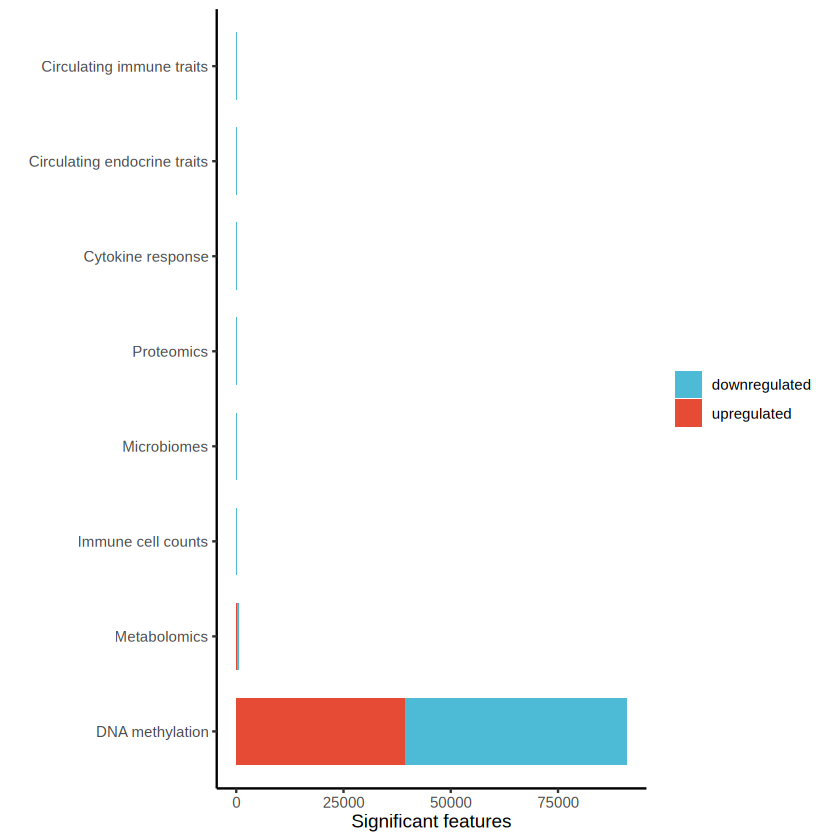

In [4]:
### feature number 
bar_df <- map2_dfr(data_list, titles, ~ tibble(
  layer = .y,
  upregulated   = sum(.x$padj < 0.05 & .x$estimate > 0, na.rm = TRUE),
  downregulated = sum(.x$padj < 0.05 & .x$estimate < 0, na.rm = TRUE)
)) %>%
  mutate(
    total = upregulated + downregulated,
    layer = fct_reorder(layer, total, .desc = TRUE)
  ) %>%
  pivot_longer(c(upregulated, downregulated), names_to = "sig", values_to = "n")

ggplot(bar_df, aes(n, layer, fill = sig)) +
  geom_col(position = "stack", width = 0.7) +
  scale_fill_manual(values = c(upregulated = "#E64B35", downregulated = "#4DBBD5")) +
  labs(x = "Significant features", y = NULL, fill = NULL) +
  theme_classic()
ggsave("/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/sig_count_barplot.pdf",
       width = 180, height = 80, units = "mm")